## Assignment 3: Pattern Mining and Recommender Systems

### Aryan Moradi, A1779263, Version 03

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [6]:
train_path = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data train.csv'
test_path  = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data test.csv'
train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)

# Exploratory Data Analysis (EDA)

In [7]:
train_df = train_df.rename(columns={"User_id": "user_id"})

In [8]:
train_df["Date"] = pd.to_datetime(train_df["Date"], format='%d/%m/%Y')

test_df["Date"] = pd.to_datetime(test_df["Date"], format='%d/%m/%Y')

In [9]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train shape: (26985, 7)
Test  shape: (19383, 7)

Columns: ['user_id', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']

Missing values (train):
 user_id            7603
Date               7603
itemDescription    7603
year               7603
month              7603
day                7603
day_of_week        7603
dtype: int64

Missing values (test):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


We first fix the inconsistency of the column name for train and test datasets. The we see that both datasets are very similar in size, 19.4k rows and 7 columns. No missing values were detected, so no immediate cleaning is required. We also parse the value of the Date column to appropriate type to be able work with it easily later on. Each row appears to represent a single item purchased by a user on a specific date so potentially we might need to consolidate all the user specific purchases on the specific date together in one row if need be.

In [10]:
train_daily = train_df.groupby('Date').size().reset_index(name='Transactions')
test_daily = test_df.groupby('Date').size().reset_index(name='Transactions')


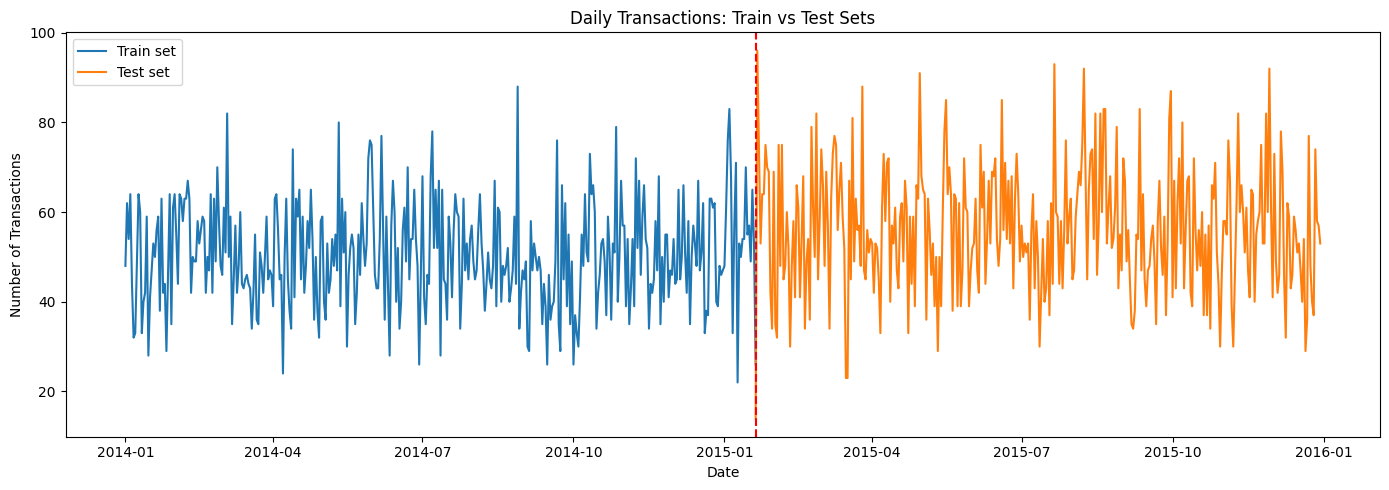

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(train_daily['Date'], train_daily['Transactions'], label='Train set')
plt.plot(test_daily['Date'], test_daily['Transactions'], label='Test set')

plt.title('Daily Transactions: Train vs Test Sets')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.axvline(x=test_daily['Date'].min(), color='r', linestyle='--', label='Train/Test Split')
plt.tight_layout()
plt.show()

We then generate the joint transaction vs date plot of train and test datasets to have general idea of how everything looks throughout the timeline. Sales volume is relatively stable week‑to‑week with mild seasonality. The 2014 series shows two noticeable dips around late April and late December, likely holiday effects. 2015 follows a similar baseline, which could mean the two datasets are comparable for modelling.

In [12]:
top20_train = train_df["itemDescription"].value_counts().head(20)
top20_test  = test_df["itemDescription"].value_counts().head(20)

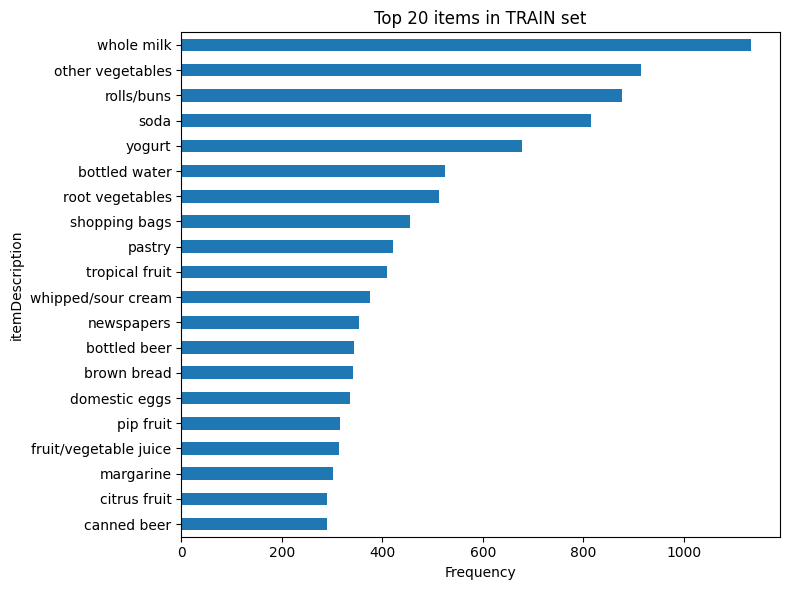

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
top20_train[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 items in TRAIN set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

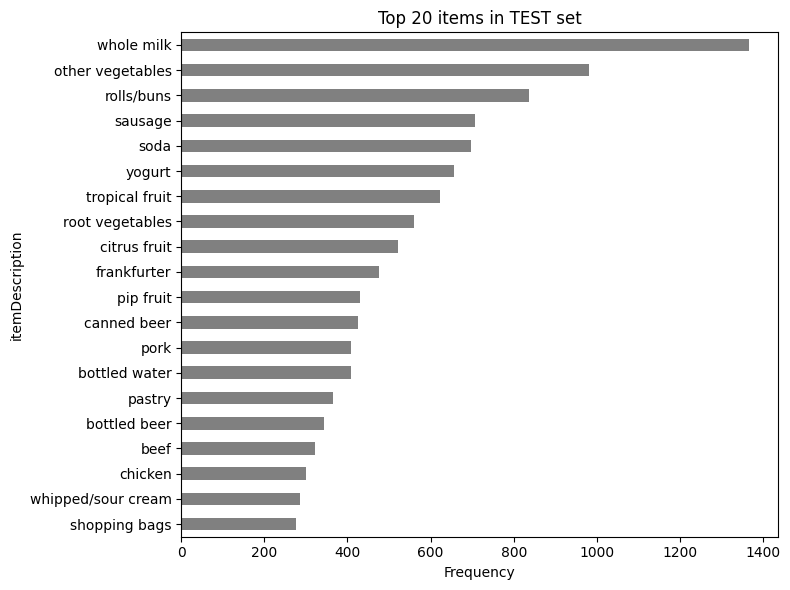

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
top20_test[::-1].plot(kind="barh", ax=ax, color="grey")
ax.set_title("Top 20 items in TEST set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

We then proceed to analyzes and visualizes the purchasing patterns in a grocery store dataset across the entire date time. The visualization shows horizontal bar charts of the top 20 most frequently purchased items in both datasets. The findings indicate that basic grocery staples dominate purchases, with "whole milk" being the most purchased item in both years, followed by "other vegetables" and "rolls/buns". The data exhibits a classic long-tail distribution, where a small number of products account for a large proportion of total sales which is a common phenomenon in retail. This pattern is valuable for inventory management and store layout planning, as it helps identify which products should be given prime shelf space and maintained in higher stock levels.

In [15]:
n_users_train = train_df["user_id"].nunique()
n_users_test  = test_df["user_id"].nunique()
print(f"Unique users in 2014 (train): {n_users_train:,}")
print(f"Unique users in 2015 (test):  {n_users_test:,}")

Unique users in 2014 (train): 3,493
Unique users in 2015 (test):  3,231


In [16]:
items_per_user = train_df.groupby("user_id")["itemDescription"].count()

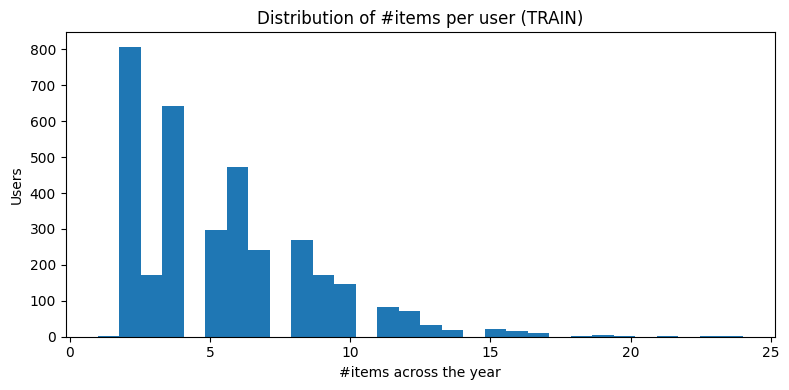

In [17]:
plt.figure(figsize=(8,4))
plt.hist(items_per_user, bins=30)
plt.title("Distribution of #items per user (TRAIN)")
plt.xlabel("#items across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We find out that there are 3,493 unique users in the training set and 3,231 unique users in the test set. Next, we generate a histogram barplot to see how many distinct items each shoppers grabbed over the whole training year. The result is sharply right-skewed as expected. Around 800 users only shopped 1-3 items all year, whereas around 650 bought 3-4, and this count continues to thin out after 10-20 items which only a fraction of users past 15 items. In other word, the dataset is dominated by light buyers with a long tail of heavy shoppers as we found previously. This will come in handy when we weight similarities such as user-user CF could over-fit those big baskets unless we normalize for basket size or down-weight high-frequency users.

In [18]:
dow_map = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train_dow = train_df["day_of_week"].value_counts().sort_index()
test_dow  = test_df["day_of_week"].value_counts().sort_index()

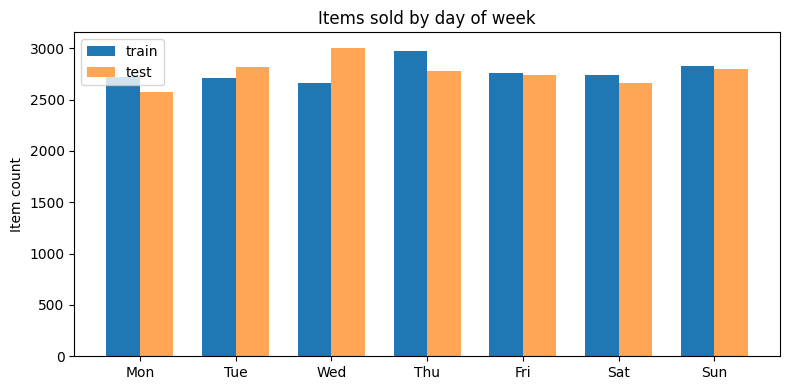

In [19]:
x = np.arange(7)
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, train_dow.values, width, label="train")
ax.bar(x + width/2, test_dow.values,  width, label="test", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(dow_map)
ax.set_title("Items sold by day of week")
ax.set_ylabel("Item count")
ax.legend()
plt.tight_layout()
plt.show()

We try to visualize a bar plot to have a better sense of the number of items bought for each day of the week. The observed pattern is pleasantly flat, which means each day hovers around 2.6-3 k items, with Thursday topping 3 k in the 2014 slice and Wednesday doing the same in 2015. Weekends don’t spike much, and Mondays drag only a touch, so demand is fairly even across the week. This is relatively good since it means we can’t blame any accuracy gaps on a weekday mismatch between the two splits.

In [20]:
train_baskets = (
    train_df
      .groupby(["user_id", "Date"])
      .size()
      .reset_index(name="items_in_basket")
)

In [21]:
baskets_per_user = train_baskets.groupby("user_id").size()

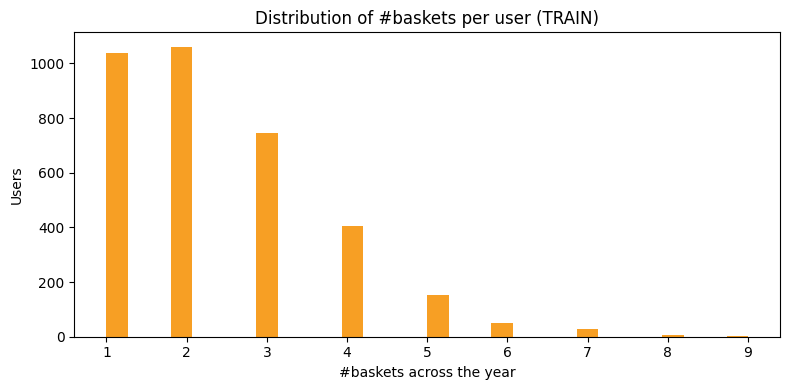

In [22]:
plt.figure(figsize=(8,4))
plt.hist(baskets_per_user, bins=30, color="#F79F24")
plt.title("Distribution of #baskets per user (TRAIN)")
plt.xlabel("#baskets across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We move on to determining some important features of the dataset we are dealing with. We know that each row of the dataset represents a singular item purchased by a specific user at a specific date, where a given user can buy the same item at multiple occasions hence why in order to have a better understanding of the baskets bought per user, we need to consolidate appropriate rows to generate the basket per transaction dataset. Once we do that, we generate a barplot to help investigate the number of baskets per user throughout the training dataset. We find out that most shoppers are truly occasional. Over half show up just once or twice all year, a further third land in the 3-4-visit range, and only a fraction pushes past five baskets. This is consistent with our findings earlier. That light-touch profile means any user-user CF model will be starved for co-occurrence data on the vast majority of customers. Hence why we might need either strong smoothing, hybrid techniques, or to lean harder on item-based signals for coverage. On the marketing side, this means the shop owners should try to get the one-time shoppers to come back for a second or third visit, instead of putting all your effort into the few people who already shop very often.

## Collaborative Filtering

In [23]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['itemDescription'].unique()
print("Number of unique users:", len(unique_users))
print("Number of unique items:", len(unique_items))

Number of unique users: 3494
Number of unique items: 168


In [24]:
min_date = train_df['Date'].min()
max_date = train_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2014-01-01 to 2015-01-20
Total days: 384


In [25]:
min_date = test_df['Date'].min()
max_date = test_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2015-01-20 to 2015-12-30
Total days: 344


In [26]:
max_date = train_df['Date'].max()
max_date

Timestamp('2015-01-20 00:00:00')

In [27]:
max_date = test_df['Date'].max()
max_date

Timestamp('2015-12-30 00:00:00')

In this version we shift our focus to refining how we generate our base utility matrix and consequently the collaborative filtering functions that will be using it. We start off by examining the exact time difference between the start and the end of the train dataset. The total days range in the train data is 384 days and for test dataset is 344 so it is slightly shorter however we must keep in mind that they are consecutive.

In [28]:
HALF_LIFE_DAYS = 180
LAMBDA = np.log(2) / HALF_LIFE_DAYS

In [29]:
days_diff = (max_date - train_df['Date']).dt.days
train_df["lambda"] = LAMBDA
train_df['days_diff'] = days_diff
train_df['weight'] = np.exp(-LAMBDA * days_diff)

In [30]:
user_item_matrix = pd.pivot_table(
        train_df,
        values='weight',
        index='user_id',
        columns='itemDescription',
        aggfunc='sum',
        fill_value=0
    )

Next, we focus on refining our understanding of the effect of the recency of each purchase. `Faggioli et al (2020)` proposed a method for taking recency in to account by first calculating the user-wise popularity of an item and later inputting that into a recency aware function with an input r, where r is the size of the recency window. The author then would use these probabilistic values to calculate the user based and item based collaborative filtering recommendations.
$$
\pi_{i}^{u}@r \;=\;
\frac{\displaystyle\sum_{t=[B_u-r]_{+}}^{B_u}
      \llbracket\, i \in b_{u}^{t}\,\rrbracket}
     {\min\!\bigl(r,\,B_u\bigr)}
$$
The literal translation of the author’s approach is that they count in how many of the last r baskets has user u bought item i, then divide by r (or by the users total basket count if they had fewer than r), then construct the utility matrix for all users with this formula for each appropriate cell, then look at people who shop like the target user.
$$
\hat{r}_{i}^{u} \;=\;
\sum_{v \in \mathcal{U}}
      w(u,v)^{q}\,\pi_{i}^{v}.
$$
If they are very similar, borrow their most-frequent items form the utility matrix that was generated and use them as weights to calculate the weighted average to score the items they bought. There are a couple of pitfalls in this approach that would not ideally work without dataset, the most important one being that the paper uses `Dunnhumby` and `Instacart`, however the resulting utility matrix for our existing dataset would turn out to be quite sparse since all the data that we have spans only two years in total with majority of the transactions being from non-frequent users. Due to this, limiting the recency window by a strict value of `r` would not provide a strong enough signal for our recommendation system to effectively produce high ranking recommendations. What we propose is a half-life exponential decay, with formula
$$
\pi_{i}^{\,v}(\lambda) \;=\;
\sum_{k=1}^{N_{(v,i)}} e^{-\lambda\,\Delta t_{(v,i,k)}}
$$

$$
\hat{r}_{i}^{\,u}(\lambda) \;=\;
\sum_{v \in \mathcal{U}}
      \bigl[w(u,v)\bigr]^{q}\,
      \pi_{i}^{\,v}(\lambda).
$$
This formula translates to looking at ALL past transactions, but shrink each one’s importance the older it is. Lambda here is the decay factor calculated based on the half-life we determine. To model recency decay in a recommendation system, we calculate λ using the following formula:

$$
\Lambda = \frac{\ln(2)}{\text{HALF\_LIFE\_DAYS}}
$$

If we for example set the half-life to 180 days, that would mean that
Items from 180 days ago have weight: 0.500
Items from 360 days ago have weight: 0.250
Items from 540 days ago have weight: 0.125
and so on. This is one of the hyperparameters that we can tune during our hyperparameter optimization on the validation set.


In [31]:
def compute_similarities(matrix, method='user'):
    if method == 'user':
        sim_matrix = cosine_similarity(matrix)
        return pd.DataFrame(sim_matrix, index=matrix.index, columns=matrix.index)
    else:  # item-item
        sim_matrix = cosine_similarity(matrix.T)
        return pd.DataFrame(sim_matrix, index=matrix.columns, columns=matrix.columns)
sim_matrix_user = compute_similarities(user_item_matrix, method='user')
sim_matrix_item = compute_similarities(user_item_matrix, method='item')

Next we choose to continue `cosine_similarity` library function from `sklearn` instead of using our own implemented version mainly since the library function calculates the resulting similarity matrix much more efficient than the our pervious implementation in version 1 and 2.

In [32]:
def generate_recommendations(user_item_matrix, sim_matrix, user_id=None, method='user', top_n=5):
    if method == 'user':
        if user_id not in user_item_matrix.index:
            return None

        # Get similar users
        similar_scores = sim_matrix.loc[user_id]
        similar_users = similar_scores.nlargest(top_n + 1).index[1:]

        # Get items bought by similar users
        user_items = user_item_matrix.loc[similar_users]

        # Weight items by user similarity
        similar_user_weights = similar_scores[similar_users].values.reshape(-1, 1)

        # Calculate the sum of weights for normalization
        weight_sum = similar_user_weights.sum()

        # Calculate weighted mean by dividing by sum of weights
        weighted_items = pd.Series(
            (user_items.values * similar_user_weights).sum(axis=0) / weight_sum,
            index=user_item_matrix.columns
        )

        # Remove items already bought by the user
        user_items = user_item_matrix.loc[user_id]
        weighted_items[user_items > 0] = 0

        return weighted_items.nlargest(top_n)


    else:   # method == 'item'
        if user_id not in user_item_matrix.index:
            return None

        user_vec = user_item_matrix.loc[user_id]
        bought_items = user_vec[user_vec > 0] # index = purchased items
        candidates = user_vec[user_vec == 0].index # unseen items

        scores = {}

        for target in candidates:
            # similarities between target item and each purchased item
            sims = sim_matrix.loc[target, bought_items.index]
            # keep top-k positive similarities
            sims_top = sims[sims > 0].sort_values(ascending=False).head(top_n)
            if sims_top.empty:
                continue

            sim_vals   = sims_top.values
            purchase_w = bought_items[sims_top.index].values

            # similarity-weighted score
            scores[target] = np.dot(sim_vals, purchase_w) / sim_vals.sum()

        if not scores:
            return None

        return (pd.Series(scores).sort_values(ascending=False).head(top_n))

Moving on, we redefine our recommendation function and fix some of the issue from version 1 and 2. In the perviosu versions, first of all we had defined two sepeate CF functions for user-user and item-item cases, whereas this can be flattend into one single function that handles both of them. Next, initially we were only taking the average of the applied weights of the similar users/items, which according to class lecture 10 notes, is wrong and we need to apply a weighted average and basically divide the resulting sum by the sum of the similar user/item similarity weights. Once we fix these issues, the overall structure of the function remains the same. For the case of user-user we first check if the specific user_id exists and return and error if nothing found. Next we look up the similarity scores between the target user and all the other users. We pick the top K most similar user to our target, which it's 5 here. After that we find the weights of the items that these similar users have bought. We then calculate a weighted average for each item by multiplying the weights of the items bought by the similar users by the similarity weigths between them and the target user. Then sum them up and divide them by the sum of the similarity weights we found earlier. Finally we remove all the items from this that our target user has already bought by setting their scores to zero again. Once that’s done we pick the top N items from the sorted list of the results which here is 5 items that are recommended. With the case of item-item, we again check the validity of the user_id passed to the function. Next we grab all the item weights the user has bought and also the items the user has not bought yet as candidate items. We initialize an empty dictionary called `scores` and we start iterating through all the candidate items to perform the calculations. For each candidate item, we look at how similar this item is to each item the user has bought using the similarity matrix specific for the item-item.  Next we keep the topN positive values, which 5 in our case, and if there are no positive values for this candidate, we skip it. This is mainly because, as per the explored example during lecture 10, we cannot consider the positive similarity weights for the items that the user themselves haven’t bought yet since doing so would lead to a multiplication by a NaN value. Moving on, we calculate the score for the target item by multiplying the similarity weight between the target item and the rest of the items we obtained by the weight score of the target users purchase, sum the up and divide by the sum of the similarity weights of the similar items we obtained and we populate the dictionary with our results. Finally, we look through the resulting scores dictionary to grab the topK, or top5 in our case, highest scores as our item-item recommendations. The intuitive way to think about it is that, item A is often bought similar to item B and item C, so we can our target user’s weighted recency rating for items B and C to with what strength would our target user buy item A.

In [33]:
# Generate user-based recommendations for user 1004
user_recommendations = generate_recommendations(
    user_item_matrix,
    sim_matrix_user,
    user_id=1004,
    method='user',
    top_n=5
)

print("Top 5 user-based recommendations for user 1004:")
for item, score in user_recommendations.items():
    print(f"- {item}: {score:.4f}")

# Generate item-based recommendations based on user
item_recommendations = generate_recommendations(
    user_item_matrix,
    sim_matrix_item,
    user_id=1004,
    method='item',
    top_n=5
)

print("\nTop 5 item-based recommendations for user 1004:")
for item, score in item_recommendations.items():
    print(f"- {item}: {score:.4f}")

# Get user's current items
user_items = user_item_matrix.loc[1004]
purchased_items = user_items[user_items > 0].sort_values(ascending=False)

print("\nUser 1004's current items:")
for item, weight in purchased_items.items():
    print(f"- {item}: {weight:.4f}")


Top 5 user-based recommendations for user 1004:
- curd: 0.0463
- cream cheese : 0.0273
- brandy: 0.0268
- specialty bar: 0.0268
- fruit/vegetable juice: 0.0224

Top 5 item-based recommendations for user 1004:
- baby cosmetics: 0.3584
- liqueur: 0.3352
- onions: 0.3056
- potato products: 0.2992
- brown bread: 0.2988

User 1004's current items:
- whole milk: 0.4146
- rolls/buns: 0.3584
- chocolate: 0.3584
- packaged fruit/vegetables: 0.1816
- shopping bags: 0.1775
- other vegetables: 0.1775
- red/blush wine: 0.1768
- root vegetables: 0.1469
- pastry: 0.1469
- pip fruit: 0.0860
- tropical fruit: 0.0860
- canned beer: 0.0620
- frozen fish: 0.0620
- dish cleaner: 0.0615
- cling film/bags: 0.0615


Finally for this version we do a basic test and print the results to have a sanity check of the results and to see if our functions is working as intended

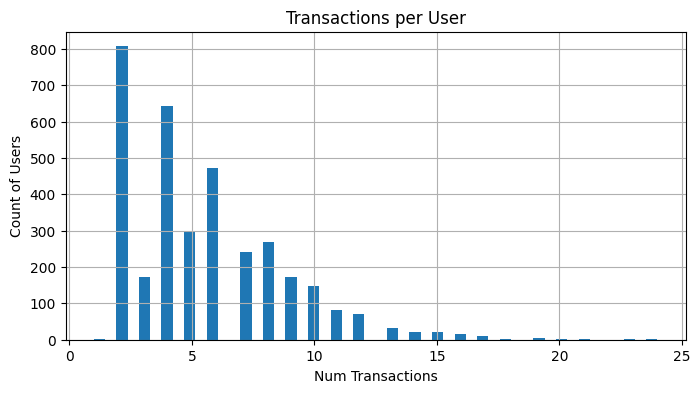

In [35]:
# 1. Transactions per user
user_counts = train_df['user_id'].value_counts()
plt.figure(figsize=(8,4))
user_counts.hist(bins=50)
plt.title('Transactions per User')
plt.xlabel('Num Transactions')
plt.ylabel('Count of Users')
plt.show()


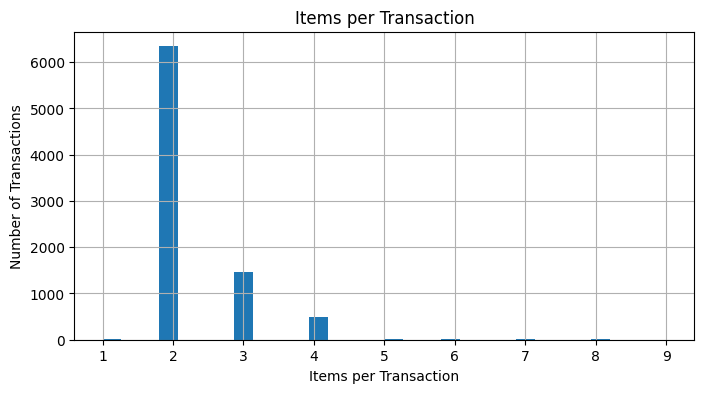

In [38]:

# 2. Transaction size distribution
#    Shows the typical number of items per basket/transaction.
transactions = train_df.groupby(['user_id','Date'])['itemDescription'].apply(list)
basket_sizes = transactions.apply(len)
plt.figure(figsize=(8,4))
basket_sizes.hist(bins=30)
plt.title('Items per Transaction')
plt.xlabel('Items per Transaction')
plt.ylabel('Number of Transactions')
plt.show()



In [39]:
# 3. Sparsity of the user–item matrix
#    High sparsity (lots of zeros) may require dimensionality reduction or regularization.
user_item = train_df.pivot_table(
    index='user_id', columns='itemDescription',
    aggfunc='size', fill_value=0
)
sparsity = 1 - (user_item.values > 0).sum() / (user_item.size)
print(f'Sparsity of user–item matrix: {sparsity:.4f}')

Sparsity of user–item matrix: 0.9686


In [40]:
# 4. Train/Test user overlap
#    Fraction of test users that appear in train—cold‐start users need fallback handling.
train_users = set(train_df['user_id'])
test_users  = set(test_df ['user_id'])
overlap_pct = len(train_users & test_users) / len(test_users) * 100
print(f'% of test users seen in train: {overlap_pct:.2f}%')

% of test users seen in train: 87.47%


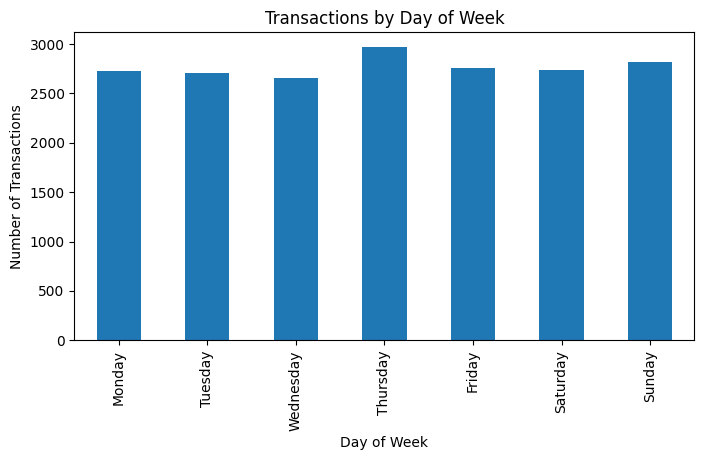

In [41]:
# 5a. Day‐of‐week seasonality
#     Reveals weekly shopping patterns (e.g. weekends vs. weekdays).
train_df['DayOfWeek'] = train_df['Date'].dt.day_name()
dow_counts = train_df['DayOfWeek']\
    .value_counts()\
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(8,4))
dow_counts.plot(kind='bar')
plt.title('Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.show()


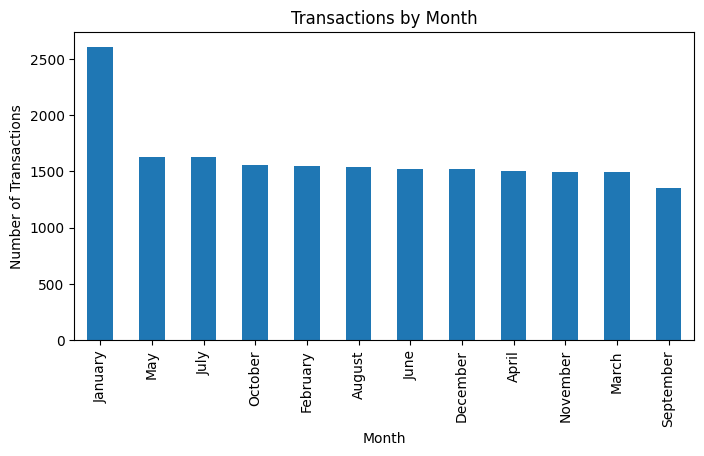

In [42]:
# 5b. Monthly seasonality
#     Reveals high‐/low‐volume months that might affect model performance.
train_df['Month'] = train_df['Date'].dt.month_name()
month_counts = train_df['Month'].value_counts()
plt.figure(figsize=(8,4))
month_counts.plot(kind='bar')
plt.title('Transactions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.show()

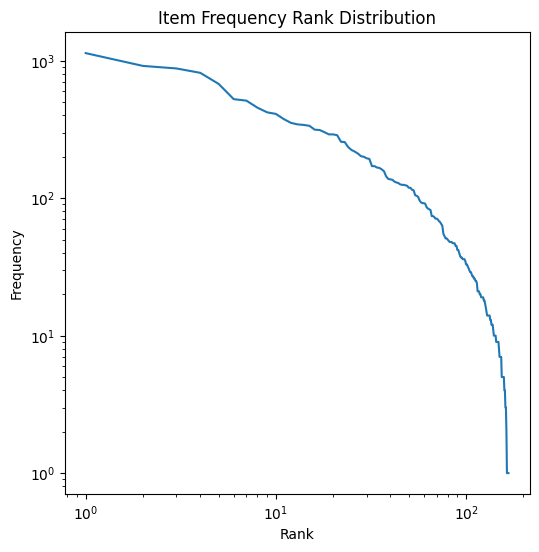

In [43]:
# 6. Long‐tail vs. head distribution
#    A log–log rank‐frequency plot to check for Pareto behavior (80/20 rule).
item_freq = train_df['itemDescription'].value_counts()
ranks = np.arange(1, len(item_freq)+1)
plt.figure(figsize=(6,6))
plt.loglog(ranks, item_freq.values)
plt.title('Item Frequency Rank Distribution')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.show()

In [44]:
# 7. Missing data & duplicates
#    Identifies any nulls or exact duplicate rows that could bias counts.
print("Missing values per column:")
print(train_df.isnull().sum())
print("Total duplicate rows:", train_df.duplicated().sum())

Missing values per column:
user_id            7603
Date               7603
itemDescription    7603
year               7603
month              7603
day                7603
day_of_week        7603
lambda                0
days_diff          7603
weight             7603
DayOfWeek          7603
Month              7603
dtype: int64
Total duplicate rows: 7880


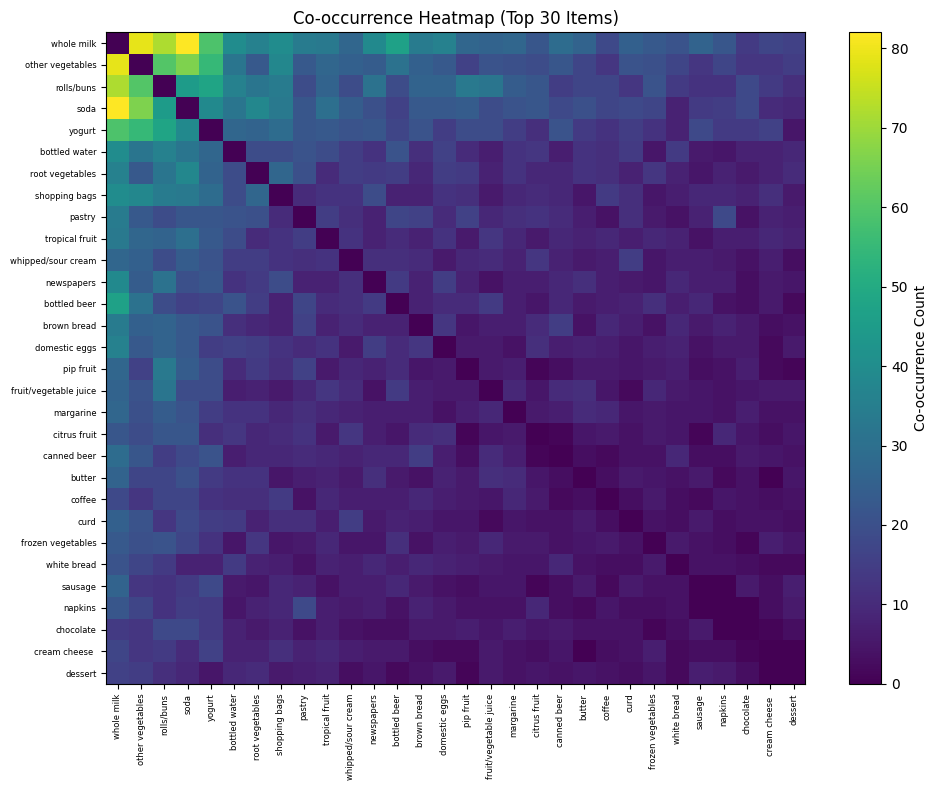

In [45]:
# 8. Co‐occurrence heatmap for top 30 items
#    Visualizes how often top items appear together in the same basket.
top_items = item_freq.head(30).index.tolist()
cooc = pd.DataFrame(0, index=top_items, columns=top_items)
for basket in transactions:
    items = [i for i in basket if i in top_items]
    for i in items:
        for j in items:
            if i != j:
                cooc.loc[i, j] += 1

plt.figure(figsize=(10,8))
plt.imshow(cooc, cmap='viridis', aspect='auto')
plt.colorbar(label='Co-occurrence Count')
plt.xticks(range(len(top_items)), top_items, rotation=90, fontsize=6)
plt.yticks(range(len(top_items)), top_items, fontsize=6)
plt.title('Co-occurrence Heatmap (Top 30 Items)')
plt.tight_layout()
plt.show()